# Catchment attributes, basin polygons, and the `base` extension

The [quickstart](quickstart.ipynb) covers the common case: pick catchments, get a daily table. This notebook covers the four things it leaves out, each of which you reach for once the daily series alone stops being enough:

| capability | what it gives you | when you need it |
|---|---|---|
| `with_attributes=True` | static catchment properties joined onto every row | regression, clustering, anything comparing catchments |
| `with_geometry=True` | the basin polygons | mapping, spatial joins, area checks |
| `version="1.2"` | an older, range-readable `base` release | reaching CAMELS/HYSETS cheaply |
| `allow_full_download=True` | the current `base` release | you actually want all ~16,300 catchments |

It closes by opening the transport directly, so the "3 MB out of 8.84 GB" claim stops being a number in a README and becomes something you can watch happen.

## Setup

Everything here is anonymous static HTTP — no credentials, no accounts.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from earthlens.caravan import Caravan, Catalog

OUT = "outputs"

2026-08-01 23:15:56 | INFO | pyramids.base.config | Logging is configured.


## 1. Static attributes

Every Caravan archive ships per-catchment attributes alongside the timeseries: where the gauge is, how big the basin is, and a set of derived climate indices (aridity, mean precipitation, snow fraction, seasonality).

`with_attributes=True` joins them onto every returned row. That is what turns a stack of hydrographs into something you can *compare* — you can only ask "do drier catchments respond differently?" once each row knows its own aridity.

Denmark is used here because it is the smallest archive (0.52 GB), so the notebook stays quick.

In [2]:
danish = Caravan(
    start="2015-01-01",
    end="2015-12-31",
    variables=["streamflow", "total_precipitation"],
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    dataset="denmark",
    country="Denmark",
    with_attributes=True,
    path=OUT,
).download(limit=2190)

2026-08-01 23:16:00.264 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:521 - caravan: indexed 625 members of caravan/denmark in 3 range requests (0.08 MB)


2026-08-01 23:16:01.367 | INFO     | earthlens.caravan.backend:_search:531 - caravan denmark: 308 catchment(s) selected from Caravan_extension_DK.zip


2026-08-01 23:16:07.395 | INFO     | earthlens.caravan.backend:_log_transfer:657 - caravan denmark: 10 range request(s), 7.42 MB transferred (archive is 0.5 GB)


2026-08-01 23:16:09.354 | INFO     | earthlens.caravan.backend:download:851 - caravan denmark: 2190 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_denmark_2025-04-11_20150101-20151231_d2284ff9.csv


The frame now carries the static columns next to the daily ones. Note they repeat per row — they describe the catchment, not the day.

In [3]:
danish[
    [
        "gauge_id",
        "date",
        "streamflow",
        "gauge_name",
        "area",
        "aridity_ERA5_LAND",
        "p_mean",
    ]
].head()

,gauge_id,date,streamflow,gauge_name,area,aridity_ERA5_LAND,p_mean
0,camelsdk_100006,2015-01-01,NaN,"V. AAGAARD, HALKAER AA",41.640713,1.607224,2.156859
1,camelsdk_100006,2015-01-02,NaN,"V. AAGAARD, HALKAER AA",41.640713,1.607224,2.156859
2,camelsdk_100006,2015-01-03,NaN,"V. AAGAARD, HALKAER AA",41.640713,1.607224,2.156859
3,camelsdk_100006,2015-01-04,NaN,"V. AAGAARD, HALKAER AA",41.640713,1.607224,2.156859
4,camelsdk_100006,2015-01-05,NaN,"V. AAGAARD, HALKAER AA",41.640713,1.607224,2.156859


### Using them: runoff ratio against aridity

With the attributes attached, a real question becomes a one-liner. The **runoff ratio** — the fraction of rainfall that leaves as streamflow — should fall as a catchment gets drier, because more water evaporates before it reaches the river.

Both `streamflow` and `total_precipitation_sum` are in mm/day, so the ratio is simply one summed over the other.

In [4]:
per_catchment = danish.groupby("gauge_id").agg(
    runoff=("streamflow", "sum"),
    rainfall=("total_precipitation_sum", "sum"),
    aridity=("aridity_ERA5_LAND", "first"),
    area=("area", "first"),
)
per_catchment["runoff_ratio"] = per_catchment["runoff"] / per_catchment["rainfall"]
per_catchment

,runoff,rainfall,aridity,area,runoff_ratio
gauge_id,,,,,
camelsdk_100006,0.00,974.59,1.607224,41.640713,0.000000
camelsdk_100009,461.53,952.32,1.682430,106.659325,0.484638
camelsdk_100010,315.48,925.19,1.823513,99.673053,0.340989
camelsdk_100011,268.98,907.08,2.091459,27.933882,0.296534
camelsdk_100013,0.00,1042.99,1.674803,52.419118,0.000000
camelsdk_100014,382.55,942.42,1.805077,90.036434,0.405923


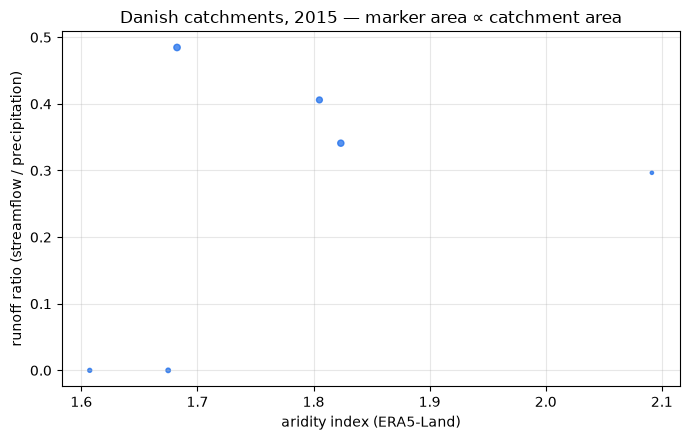

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(
    per_catchment["aridity"],
    per_catchment["runoff_ratio"],
    s=per_catchment["area"] / 5,
    alpha=0.75,
    color="#1f6feb",
)
ax.set_xlabel("aridity index (ERA5-Land)")
ax.set_ylabel("runoff ratio (streamflow / precipitation)")
ax.set_title("Danish catchments, 2015 — marker area ∝ catchment area")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Three catchments is far too few to claim a relationship — the point is that the *question* is now expressible. Run the same cell against `dataset="grdc"` with a wide bounding box and the scatter becomes a real climate gradient.

## 2. Basin polygons

`with_geometry=True` additionally reads the basin shapefiles. The polygons do not go into the frame — they would repeat once per row — so they are attached to the backend as `.geometry`, a `pyramids` `FeatureCollection`.

This is why the backend object is worth keeping rather than discarding after `download()`.

In [6]:
source = Caravan(
    start="2015-01-01",
    end="2015-01-31",
    variables=["streamflow"],
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    dataset="denmark",
    country="Denmark",
    with_geometry=True,
    path=OUT,
)
frame = source.download(limit=93)
basins = source.geometry
type(basins).__name__

2026-08-01 23:16:11.796 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:521 - caravan: indexed 625 members of caravan/denmark in 3 range requests (0.08 MB)


2026-08-01 23:16:13.539 | INFO     | earthlens.caravan.backend:_search:531 - caravan denmark: 308 catchment(s) selected from Caravan_extension_DK.zip


2026-08-01 23:16:15.961 | INFO     | earthlens.caravan.backend:_log_transfer:657 - caravan denmark: 7 range request(s), 4.27 MB transferred (archive is 0.5 GB)


2026-08-01 23:16:18.978 | INFO     | earthlens.caravan.backend:download:851 - caravan denmark: 93 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_denmark_2025-04-11_20150101-20150131_d2284ff9.csv


'FeatureCollection'

The collection proxies its underlying `GeoDataFrame`, so it plots and measures directly. Every Danish basin is included — the shapefile is per *source dataset*, not per selected catchment.

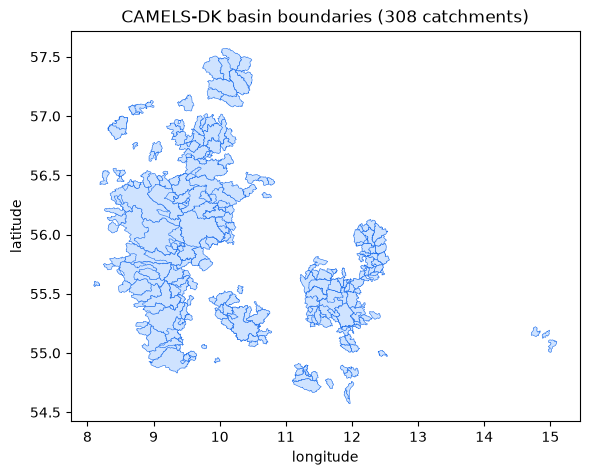

In [7]:
fig, ax = plt.subplots(figsize=(6, 7))
basins.plot(ax=ax, facecolor="#cfe3ff", edgecolor="#1f6feb", linewidth=0.4)
ax.set_title(f"CAMELS-DK basin boundaries ({len(basins)} catchments)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.tight_layout()
plt.show()

## 3. The `base` extension is guarded

`base` is where CAMELS-US, CAMELS-AUS, CAMELS-BR, CAMELS-CL, CAMELS-GB, HYSETS and LamaH-CE live — roughly two-thirds of all Caravan catchments. It is also the one release that is **not** range-readable: since v1.4 it ships as a single `.tar.gz`, a gzip stream with no directory, so reaching one catchment means transferring all 25–29 GB of it.

Requesting it therefore raises rather than quietly starting that download.

In [8]:
try:
    Caravan(
        start="2000-01-01",
        end="2000-01-05",
        variables=["streamflow"],
        lat_lim=[-90, 90],
        lon_lim=[-180, 180],
        dataset="base",
        gauge_ids=["camels_01022500"],
        path=OUT,
    )
except ValueError as exc:
    print(exc)

the 'base' extension at version '1.6' ships as a tar.gz (29.0 GB), which cannot be read in place - reaching one catchment means downloading all of it. Pass allow_full_download=True to accept that transfer. Pass version='1.2' to read a range-accessible release instead (note it is an older, smaller release).


The message names both ways forward. `allow_full_download=True` accepts the transfer; `version="1.2"` reaches CAMELS through the last release that was still a ZIP, and therefore still range-readable.

The cheap route is not a free lunch, and the catalog records why.

In [9]:
base = Catalog().get_extension("base")
pd.DataFrame(
    [
        {
            "version": key,
            "catchments": release.n_catchments,
            "measured?": release.n_catchments_verified,
            "period": release.data_period,
            "columns": release.column_set,
            "format": release.file_for("csv").archive_format,
            "GB": round(release.file_for("csv").size / 1e9, 1),
        }
        for key, release in sorted(base.versions.items())
    ]
)

,version,catchments,measured?,period,columns,format,GB
0,1.2,6830,True,"(1981, 2020)",legacy,zip,12.5
1,1.6,16300,False,"(1950, 2023)",current,tar.gz,29.0


`1.2` is a **materially different dataset**, not merely an older cut: 43% of the catchments, forcing ending in 2020 rather than 2023, and the `legacy` column set — one `potential_evaporation_sum` instead of the ERA5-Land/FAO pair the current releases split it into.

Ask for `potential_evaporation` against it and the backend resolves the legacy name for you.

In [10]:
camels = Caravan(
    start="2000-01-01",
    end="2000-01-10",
    variables=["streamflow", "potential_evaporation"],
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    dataset="base",
    version="1.2",
    gauge_ids=["camels_01022500", "hysets_01010070"],
    path=OUT,
).download()
camels

2026-08-01 23:16:23.789 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:521 - caravan: indexed 13768 members of caravan/base in 5 range requests (1.87 MB)


2026-08-01 23:16:23.808 | INFO     | earthlens.caravan.backend:_search:531 - caravan base: 2 catchment(s) selected from Caravan.zip


2026-08-01 23:16:25.844 | INFO     | earthlens.caravan.backend:_log_transfer:657 - caravan base: 7 range request(s), 3.97 MB transferred (archive is 12.5 GB)


2026-08-01 23:16:25.846 | INFO     | earthlens.caravan.backend:download:851 - caravan base: 20 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_base_1-2_20000101-20000110_5cbd09bc.csv


,gauge_id,date,streamflow,potential_evaporation_sum
0,camels_01022500,2000-01-01,1.06,4.32
1,camels_01022500,2000-01-02,1.13,1.95
2,camels_01022500,2000-01-03,1.40,7.80
3,camels_01022500,2000-01-04,1.49,2.78
4,camels_01022500,2000-01-05,3.79,15.51
5,camels_01022500,2000-01-06,4.37,9.28
6,camels_01022500,2000-01-07,4.00,2.33
7,camels_01022500,2000-01-08,3.21,11.15
8,camels_01022500,2000-01-09,2.47,7.14
9,camels_01022500,2000-01-10,2.09,4.32


Two catchments from two different national datasets — CAMELS-US and HYSETS — in one frame with one schema. That interoperability is the whole reason Caravan exists.

## 4. Watching the transport

Everything above rests on one idea: a ZIP stores its file directory at the *tail*, so with HTTP range requests you can read that directory and then pull single members, without the rest of the archive ever crossing the network.

`transfer_stats` reports what a request actually cost, so the claim is checkable rather than asserted.

In [11]:
grdc = Caravan(
    start="2010-01-01",
    end="2010-12-31",
    variables=["streamflow"],
    lat_lim=[-90, 90],
    lon_lim=[-180, 180],
    dataset="grdc",
    gauge_ids=["GRDC_1159100"],
    path=OUT,
)
rows = grdc.download()
archive = grdc._open_archive()
requests_made, transferred_mb = archive.transfer_stats
archive_gb = grdc.archive_file.size / 1e9
print(f"{len(archive.members)} members indexed, {len(rows)} rows returned")
print(
    f"{transferred_mb:.2f} MB in {requests_made} requests, from a {archive_gb:.2f} GB archive"
)

2026-08-01 23:16:29.363 | DEBUG    | earthlens.caravan._helpers:open_remote_zip:521 - caravan: indexed 5367 members of caravan/grdc in 4 range requests (0.81 MB)


2026-08-01 23:16:29.484 | INFO     | earthlens.caravan.backend:_search:531 - caravan grdc: 1 catchment(s) selected from GRDC_Caravan_extension_csv.zip


2026-08-01 23:16:31.386 | INFO     | earthlens.caravan.backend:_log_transfer:657 - caravan grdc: 6 range request(s), 2.91 MB transferred (archive is 8.8 GB)


2026-08-01 23:16:31.389 | INFO     | earthlens.caravan.backend:download:851 - caravan grdc: 365 row(s) written to C:\python-environments\worktrees\earthlens\caravan\docs\examples\caravan\outputs\caravan_grdc_0-6_20100101-20101231_e38e2db7.csv


5367 members indexed, 365 rows returned
2.91 MB in 6 requests, from a 8.84 GB archive


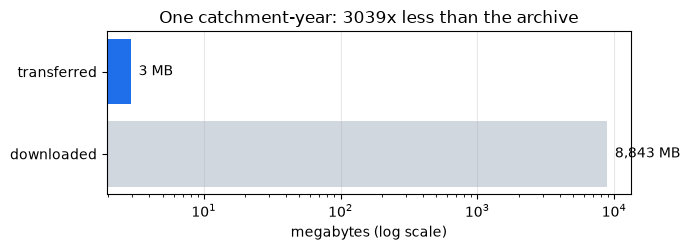

In [12]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(
    ["downloaded", "transferred"],
    [archive_gb * 1000, transferred_mb],
    color=["#d0d7de", "#1f6feb"],
)
ax.set_xscale("log")
ax.set_xlabel("megabytes (log scale)")
ax.set_title(
    f"One catchment-year: {archive_gb * 1000 / transferred_mb:.0f}x less than the archive"
)
for index, value in enumerate([archive_gb * 1000, transferred_mb]):
    ax.text(value, index, f"  {value:,.0f} MB", va="center")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

Closing the backend releases the archive handle and the HTTP session. `download()` deliberately does not do it for you, because the statistics above live on the archive.

In [13]:
grdc.close()
source.close()

## Takeaway

- **`with_attributes=True`** turns per-catchment series into something comparable — the runoff-ratio-against-aridity question needs it.
- **`with_geometry=True`** attaches basin polygons to `.geometry`, not to the frame, because they describe the catchment rather than the day.
- **`base` is gated**, and the error names both escapes. `version="1.2"` is cheap but is a smaller, older, differently-columned dataset — check the version table before treating it as a substitute.
- **`transfer_stats`** makes the range-read design auditable from your own session.

Next: the [extension table](../../reference/caravan/datasets.md) for what each release contains, and [usage](../../reference/caravan/usage.md) for the full option surface.